In [1]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy
import numpy as np
from collections import defaultdict
import sys, os

In [3]:
def traverse_folder(folder_data, folder_path, graph, parent=None):
    """Traverse folder structure recursively"""
    pristine_count = 0
    lost_count = 0
    replica_count = 0
    total_files = 0

    graph.add_node(folder_path, node_type='folder')

    if parent:
        graph.add_edge(parent, folder_path)

    if 'files' in folder_data:
        for filename, file_info in folder_data['files'].items():
            status = file_info.get('status', 'unknown')
            total_files += status[ "lost" ] + status[ "pristine" ] + status[ "replica" ]

            file_path = f"{folder_path}/{filename}"
            graph.add_node(file_path, node_type='file')
            graph.add_edge(folder_path, file_path)

            graph.nodes[file_path]['file_status'] = status
            pristine_count += status[ "pristine" ]
            lost_count += status[ "lost" ]
            replica_count += status[ "replica" ]

    if 'folders' in folder_data:
        for subfolder_name, subfolder_data in folder_data['folders'].items():
            subfolder_path = f"{folder_path}/{subfolder_name}"
            sub_pristine, sub_lost, sub_replica, sub_total = traverse_folder(
                subfolder_data, subfolder_path, graph, folder_path
            )
            pristine_count += sub_pristine
            lost_count += sub_lost
            replica_count += sub_replica
            total_files += sub_total

    graph.nodes[folder_path]['pristine_count'] = pristine_count
    graph.nodes[folder_path]['lost_count'] = lost_count
    graph.nodes[folder_path]['replica_count'] = replica_count
    graph.nodes[folder_path]['total_files'] = total_files

    return pristine_count, lost_count, replica_count, total_files

In [4]:
# json_file = "wannacry-60-sss_ransomware-1-report.json"
json_file = "Globeimposter-30-ON_THE_FLY-tree_aggregate_report.json"
# json_file = "phobos-60-sss_ransomware-1-report.json"
# json_file = "lockbit-60-sss_ransomware-1-report.json"
with open(json_file, 'r') as f:
        data = json.load(f)

G = nx.Graph()
root_path = data['root']

# Add root node
G.add_node(root_path, node_type='folder')
total_pristine = 0
total_lost = 0
total_replica = 0
total_files = 0

if 'files' in data['files']:
        for filename, file_info in data['files'].items():
            
            status = file_info.get('status', 'unknown')
            total_files += status[ "lost" ] + status[ "pristine" ] + status[ "replica" ]

            file_path = f"{root_path}/{filename}"
            G.add_node(file_path, node_type='file')
            G.add_edge(root_path, file_path)

            G.nodes[file_path]['file_status'] = status
            pristine_count += status[ "pristine" ]
            lost_count += status[ "lost" ]
            replica_count += status[ "replica" ]
            
if 'folders' in data:
    for folder_name, folder_data in data['folders'].items():
        folder_path = f"{root_path}/{folder_name}"
        p, l, r, t = traverse_folder(folder_data, folder_path, G, root_path)
        total_pristine += p
        total_lost += l
        total_replica += r
        total_files += t

G.nodes[root_path]['pristine_count'] = total_pristine
G.nodes[root_path]['lost_count'] = total_lost
G.nodes[root_path]['replica_count'] = total_replica
G.nodes[root_path]['total_files'] = total_files

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Root: {root_path}")

Graph: 2643 nodes, 2642 edges
Root: C:/users/IEuser


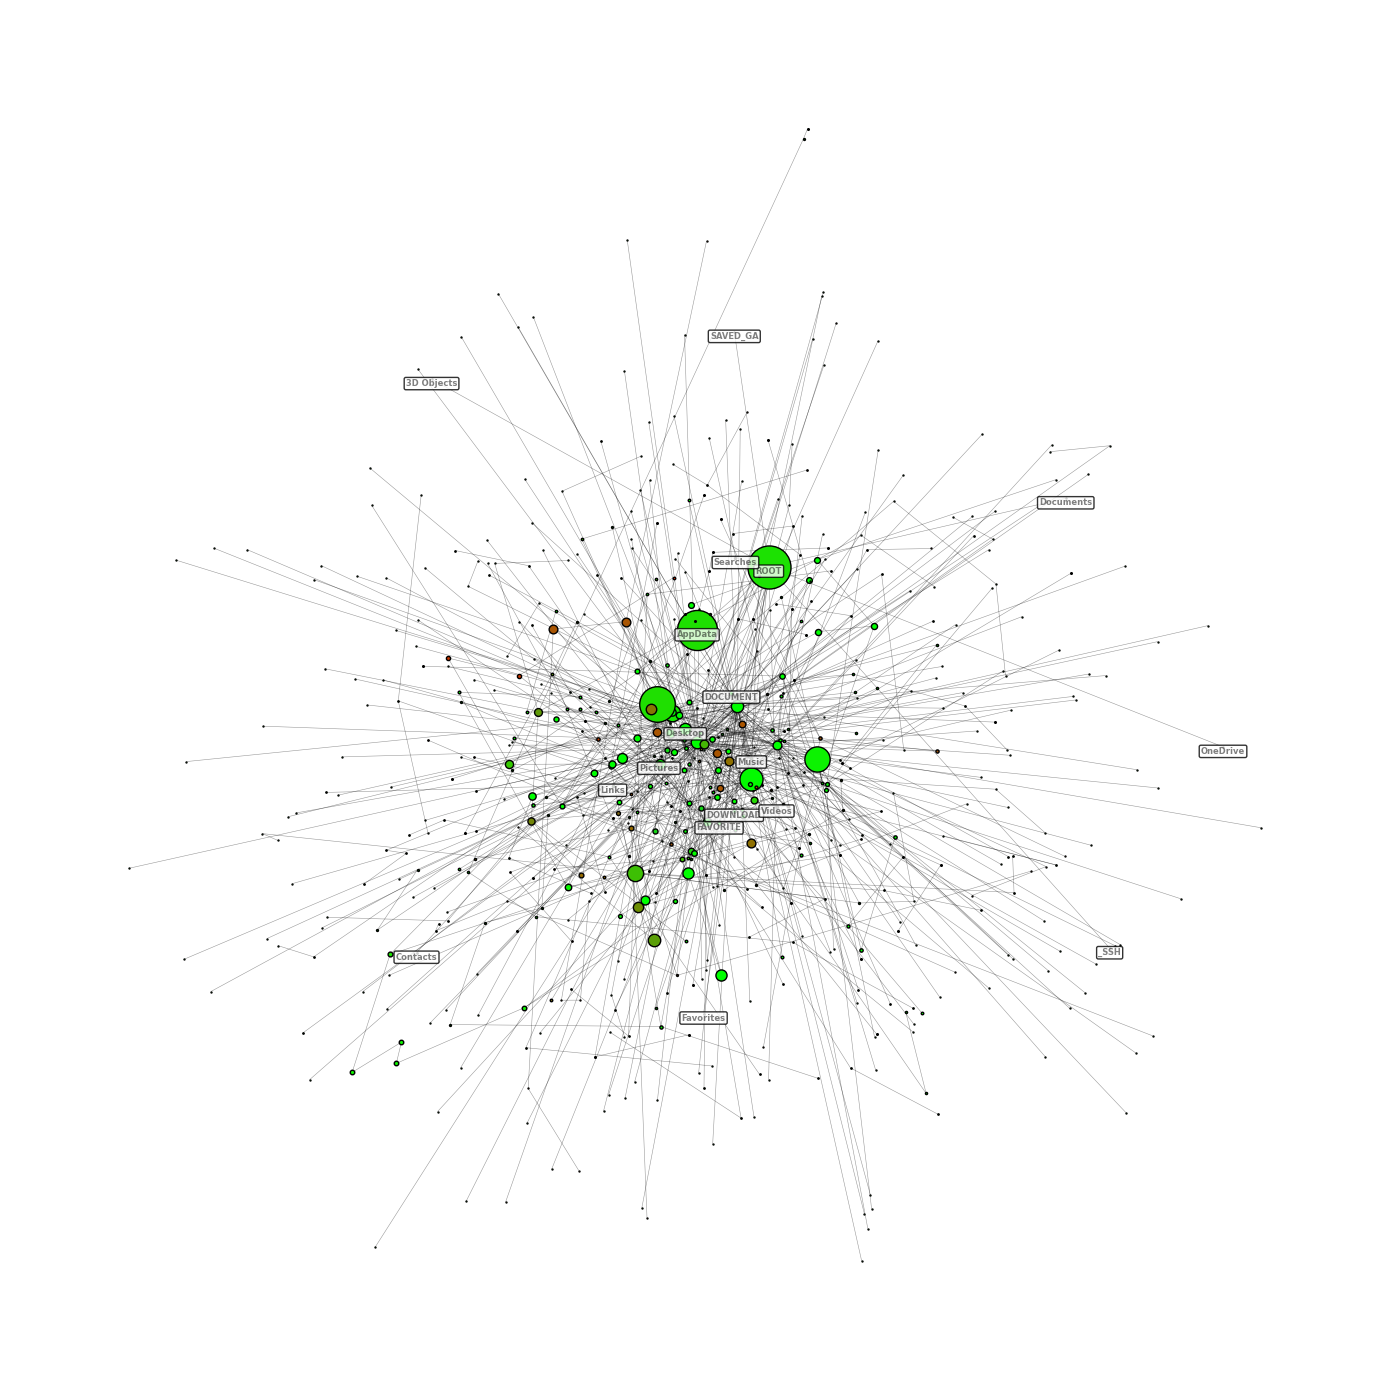

In [18]:
G_weighted = G.copy()

# Precompute folder sizes
folder_sizes = {
    n: G.nodes[n].get("total_files", 0)
    for n, d in G.nodes(data=True)
    if d.get("node_type") == "folder"
}

max_folder_size = max(folder_sizes.values()) or 1

for u, v in G_weighted.edges():
    u_type = G_weighted.nodes[u].get("node_type")
    v_type = G_weighted.nodes[v].get("node_type")

    weight = 1.0
    if u_type == v_type: # there cannot be file-file edges

        min_size = min(folder_sizes[v],folder_sizes[u])
        max_size = max(folder_sizes[v],folder_sizes[u])

        size_ratio = (max_size-min_size)/max_size

        # smaller weight -> longer springs -> farther
        max_w = 2.0
        weight = max_w - size_ratio * max_w
    else: # file-to-folder
        size = 1.0
        if u_type == "folder":
            size = folder_sizes[u]
        else:
            size = folder_sizes[v] 
        weight = 25.0/size

    G_weighted[u][v]["weight"] = weight

pos = nx.spring_layout(
    G_weighted, 
    k=1.0,              # Lower k -> nodes closer together (default is ~0.3)
    iterations=10,    # More iterations -> better convergence
    weight='weight',    # Use edge weights
    scale=1.0,          # Lower scale = more compact (default is 1.0)
    seed=42
)

fig, ax = plt.subplots(figsize=(14, 14), facecolor='white')

# Separate nodes by type
folder_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'folder']
file_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'file']

# Calculate total files for sizing
total_file_count = max(sum([G.nodes[n].get('total_files', 0) for n in folder_nodes]), 1)

# Draw edges
folder_edges = [(u, v) for u, v in G.edges() 
                if G.nodes[u].get('node_type') == 'folder' 
                and G.nodes[v].get('node_type') == 'folder']
file_edges = [(u, v) for u, v in G.edges() 
              if (G.nodes[u].get('node_type') == 'file') 
              or (G.nodes[v].get('node_type') == 'file')]

# Folder-folder edges (thicker)
nx.draw_networkx_edges(G, pos, edgelist=folder_edges, 
                      alpha=0.4, width=0.4, edge_color="#000000", ax=ax)

# File-folder edges (thinner)
# nx.draw_networkx_edges(G, pos, edgelist=file_edges, 
#                       alpha=0.2, width=0.2, edge_color="#000000", ax=ax)

# Draw file nodes (colored by status mix)
# for fn in file_nodes:
#     status = G.nodes[ fn ].get('file_status')
#     color = (status[ "lost_p" ], status[ "pristine_p" ], status[ "replica_p" ])
#     nx.draw_networkx_nodes(G, pos, node_color=( color ), node_size=10, alpha=1, ax=ax)

# Draw folder nodes with color based on file composition
for folder_node in folder_nodes:
    pristine = G.nodes[folder_node].get('pristine_count', 0)
    lost = G.nodes[folder_node].get('lost_count', 0)
    replica = G.nodes[folder_node].get('replica_count', 0)
    total = pristine + lost + replica
    
    if total > 0:
        # Calculate color mixture (green for pristine, red for lost, blue for replicas)
        pristine_ratio = pristine / total
        lost_ratio = lost / total
        replica_ratio = replica / total
        
        r = lost_ratio
        g = pristine_ratio
        b = replica_ratio
        color = (r, g, b)
    else:
        color = (0.1, 0.1, 0.1)  # Lightgray for empty folders
    
    # Size based on file count
    file_count = G.nodes[folder_node].get('total_files', 0)
    
    size = (file_count / total_file_count) * 6000
    nx.draw_networkx_nodes(G, pos, nodelist=[folder_node],
                            node_color=[color], node_size=size, 
                            alpha=1, ax=ax, node_shape='o',
                            edgecolors='black', linewidths=1)

# Draw folder labels BELOW nodes in BLACK
folder_labels = {}
label_pos = {}

for folder_node in folder_nodes:
    if folder_node == root_path:
        folder_labels[folder_node] = 'ROOT'
    else:
        # Get the parent folder by removing the n-th component
        parent_folder = []
        levels = 2
        for level in range(1,levels):
            parent_folder.append( '/'.join(folder_node.split('/')[:-level]) )
        
        # Only add if this folder is a n-level child of ROOT
        if root_path in parent_folder:
            folder_name = folder_node.split('/')[-1]
            folder_labels[folder_node] = folder_name
    
    # label offset
    x, y = pos[folder_node]
    label_pos[folder_node] = (x, y)  # Adjust offset

bbox_props = dict(
    boxstyle="round,pad=0.2",   
    facecolor="white",          
    edgecolor="black",          
    alpha=0.8                   
)

nx.draw_networkx_labels(G, label_pos, folder_labels, font_size=6, 
                       font_weight='bold', font_color='black', alpha=0.5, 
                       verticalalignment='top', bbox=bbox_props, ax=ax)

# Legend
# legend_elements = [
#     mpatches.Patch(color='green', label='Pristine files'),
#     mpatches.Patch(color='red', label='Lost files (no replicas)'),
#     mpatches.Patch(color='blue', label='Lost files (with replicas)'),
#     mpatches.Patch(color='gray', label='Folders (color = composition)')
# ]
# ax.legend(handles=legend_elements, loc='upper right', fontsize=10, 
#          framealpha=0.95, edgecolor='black')

ax.axis('off')
plt.tight_layout()

# Save the figure
# plt.savefig(f"{os.path.splitext(json_file)[0]}.pdf", dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f"{os.path.splitext(json_file)[0]}.png", dpi=300, bbox_inches='tight', facecolor='white')

plt.show()
